In [1]:
import sys
from pathlib import Path


# Ajoute src/ au path pour pouvoir faire `from ingest import ...`
SRC_DIR = Path("../src").resolve()  # ajuste selon la position réelle du notebook
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

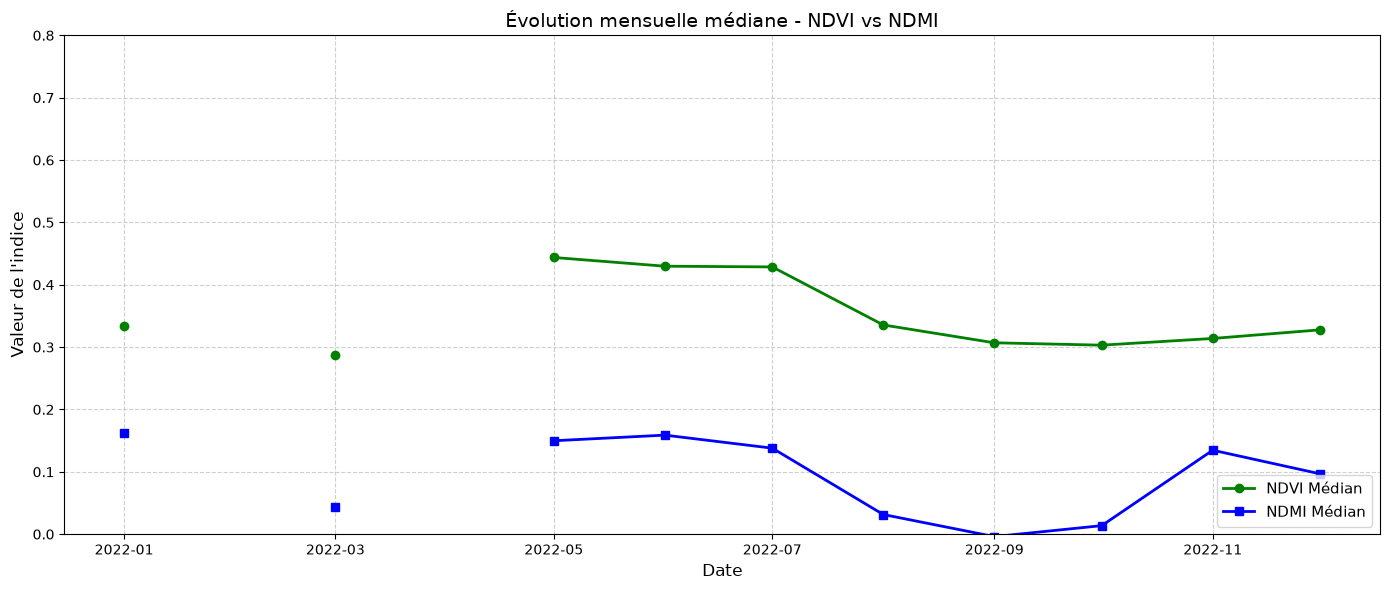

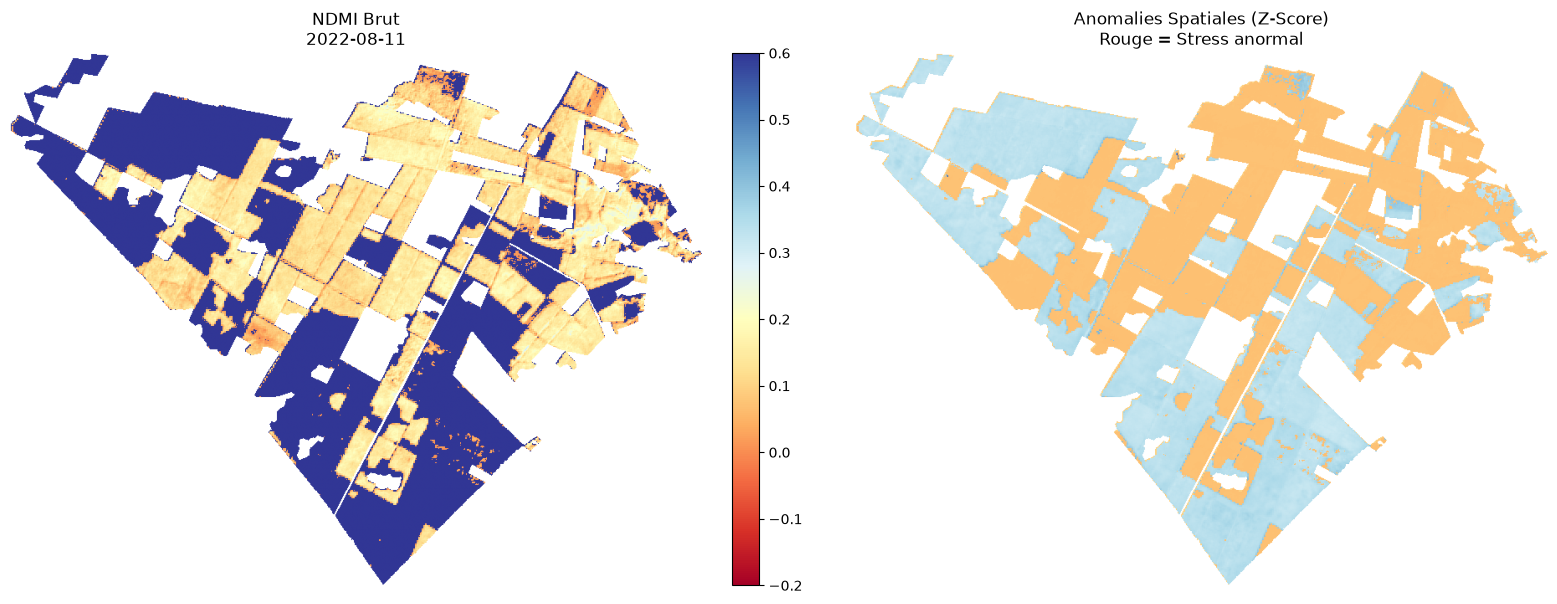

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
from ingest import load_manifest, get_usable_scenes, get_band_path
from ingest.raster import load_band_with_aoi_mask
from ingest.search import load_aoi

# Import de ton package de visualisation !
from analysis import plot_timeseries, plot_spatial_anomaly

# --- 1. Setup ---
OUTPUT_DIR = Path("../data/ingested")
ZONE_NAME = "pins_1"
GEOJSON_PATH = OUTPUT_DIR.parent / "parcelles/gironde/pins_1.geojson"

zone_dir = OUTPUT_DIR / ZONE_NAME
manifest = load_manifest(zone_dir)
scenes = get_usable_scenes(manifest)
aoi_geom, _, _ = load_aoi(GEOJSON_PATH)

# --- 2. Série Temporelle ---
results = []
for sc in scenes:
    b04, outside = load_band_with_aoi_mask(zone_dir / get_band_path(sc, "B04_10m"), aoi_geom, "EPSG:4326")
    b08, _       = load_band_with_aoi_mask(zone_dir / get_band_path(sc, "B08_10m"), aoi_geom, "EPSG:4326")
    b11_20m, _   = load_band_with_aoi_mask(zone_dir / get_band_path(sc, "B11_20m"), aoi_geom, "EPSG:4326")
    
    b11 = np.repeat(np.repeat(b11_20m, 2, axis=0), 2, axis=1)[:b08.shape[0], :b08.shape[1]]
    outside = outside[:b08.shape[0], :b08.shape[1]]
    
    # IL FAUT ABSOLUMENT CONVERTIR EN FLOAT ICI !
    b04 = b04.astype(float)
    b08 = b08.astype(float)
    b11 = b11.astype(float)
    
    ndvi = np.divide((b08 - b04), (b08 + b04), out=np.zeros_like(b08), where=(b08 + b04) != 0)
    ndvi[outside] = np.nan
    
    ndmi = np.divide((b08 - b11), (b08 + b11), out=np.zeros_like(b08), where=(b08 + b11) != 0)
    ndmi[outside] = np.nan
    
    results.append({
        "date": pd.to_datetime(sc["datetime"][:10]),
        "ndvi_median": np.nanmedian(ndvi),
        "ndmi_median": np.nanmedian(ndmi)
    })

df = pd.DataFrame(results).sort_values("date").set_index('date')
df_monthly = df.resample('MS').median()

# >>> APPEL DE LA VISU <<<
plot_timeseries(df_monthly)


# --- 3. Anomalie Spatiale ---
date_cible = pd.to_datetime("2022-08-15")
scene_ete = min(scenes, key=lambda s: abs(pd.to_datetime(s['datetime'][:10]) - date_cible))

b08, outside = load_band_with_aoi_mask(zone_dir / get_band_path(scene_ete, "B08_10m"), aoi_geom, "EPSG:4326")
b11_20m, _   = load_band_with_aoi_mask(zone_dir / get_band_path(scene_ete, "B11_20m"), aoi_geom, "EPSG:4326")
b11 = np.repeat(np.repeat(b11_20m, 2, axis=0), 2, axis=1)[:b08.shape[0], :b08.shape[1]]

ndmi_ete = np.divide((b08 - b11), (b08 + b11), out=np.zeros_like(b08, dtype=float), where=(b08 + b11) != 0)
ndmi_ete[outside[:b08.shape[0], :b08.shape[1]]] = np.nan

# Z-Score
mean_ndmi = np.nanmean(ndmi_ete)
std_ndmi = np.nanstd(ndmi_ete)
z_score = (ndmi_ete - mean_ndmi) / std_ndmi
anomaly_mask = z_score < -1.5

# >>> APPEL DE LA VISU <<<
plot_spatial_anomaly(ndmi_ete, z_score, anomaly_mask, scene_ete['datetime'][:10])